# Preprocess data to be used in ABM

## Python_grid.xlsx

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
py_grid_raw = pd.read_excel("raw_data/Python_grid.xlsx", sheet_name="Hoja1")
py_grid = pd.DataFrame()
py_grid["x"] = py_grid_raw["x_centroid"]
py_grid["y"] = py_grid_raw["y_centroid"]
py_grid["soil"] = py_grid_raw["soil_code"]
py_grid["hydro"] = py_grid_raw["hydro_code"]

In [ ]:
py_grid.replace("<Null>", pd.NA, inplace=True)
py_grid.dropna(subset=["x", "y"], inplace=True)

# Reemplaça soil==9 pel valor del veí més proper amb soil==1, soil==2 o soil==3
from sklearn.neighbors import NearestNeighbors
mask_9 = py_grid["soil"] == 9
mask_123 = py_grid["soil"].isin([1, 2, 3])
if mask_9.any() and mask_123.any():
    neigh = NearestNeighbors(n_neighbors=1)
    neigh.fit(py_grid.loc[mask_123, ["x", "y"]])
    distances, indices = neigh.kneighbors(py_grid.loc[mask_9, ["x", "y"]])
    py_grid.loc[mask_9, "soil"] = py_grid.loc[mask_123, "soil"].iloc[indices.flatten()].values

py_grid.to_csv("input_data/preprocessed_grid.csv", index=False)

In [87]:
print(py_grid_raw["soil_label"].unique())
print(py_grid_raw["soil_note"].unique())
print(py_grid_raw["soil_code"].unique())
display(py_grid_raw[py_grid_raw["soil_label"]=="unknown"])

<StringArray>
['petric_calcisol', 'unknown', 'alluvial_fluvisol', '<Null>',
 'eolian_arenosol']
Length: 5, dtype: str
<StringArray>
['Petric Calcisol; calcic soil with possible rooting limitations',
                          'Unclassified or missing soil category',
    'Eutric Fluvisol; alluvial soil; high agricultural potential',
                                                         '<Null>',
     'Haplic Arenosol / eolian sandy soil; lower water retention']
Length: 5, dtype: str
[2 9 1 3]


,OBJECTID *,Shape *,cell_id,area_ha,x_centroid,y_centroid,cultivable,Lithology,CLAF_FAO,soil_code,...,soil_note,TunGLG,TunHGComb,hydro_code,hydro_label,hydro_note,dist_river_m,dist_road_m,Shape_Length,Shape_Area
4,5,Polygon Z,5,0.25,650421.4429,3888529.5713,1,UC,RGc,9,...,Unclassified or missing soil category,Unconsolidated,U-H,1,high_groundwater,Unconsolidated aquifer; high productivity,1562.111607,7787.255835,200.0,2500.0
6,7,Polygon Z,7,0.25,660371.4429,3887529.5713,1,UC,RGc,9,...,Unclassified or missing soil category,Unconsolidated,U-H,1,high_groundwater,Unconsolidated aquifer; high productivity,320.523879,1508.526293,200.0,2500.0
7,8,Polygon Z,8,0.25,650021.4429,3888829.5713,1,UC,RGc,9,...,Unclassified or missing soil category,Unconsolidated,U-H,1,high_groundwater,Unconsolidated aquifer; high productivity,1263.666344,8101.016489,200.0,2500.0
8,9,Polygon Z,9,0.25,650121.4429,3887029.5713,1,SO2,CLl,9,...,Unclassified or missing soil category,Unconsolidated,U-H,1,high_groundwater,Unconsolidated aquifer; high productivity,1969.749218,8448.433725,200.0,2500.0
12,13,Polygon Z,13,0.25,654321.4429,3888779.5713,1,UC,RGc,9,...,Unclassified or missing soil category,Unconsolidated,U-H,1,high_groundwater,Unconsolidated aquifer; high productivity,1165.069033,3945.875103,200.0,2500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
635904,635905,Polygon Z,635905,0.25,651521.4429,3886529.5713,1,UC,RGc,9,...,Unclassified or missing soil category,Unconsolidated,U-H,1,high_groundwater,Unconsolidated aquifer; high productivity,1272.440129,7266.139841,200.0,2500.0
635908,635909,Polygon Z,635909,0.25,651621.4429,3886629.5713,1,UC,RGc,9,...,Unclassified or missing soil category,Unconsolidated,U-H,1,high_groundwater,Unconsolidated aquifer; high productivity,1375.996346,7139.311572,200.0,2500.0
635909,635910,Polygon Z,635910,0.25,660321.4429,3885629.5713,1,UC,RGc,9,...,Unclassified or missing soil category,Cretaceous-Tertiary sedimentary,CSIF-M,2,medium_groundwater,Sedimentary aquifer; medium productivity,744.866344,1056.110335,200.0,2500.0
635910,635911,Polygon Z,635911,0.25,656771.4429,3886229.5713,1,UC,RGc,9,...,Unclassified or missing soil category,Cretaceous-Tertiary sedimentary,CSIF-M,2,medium_groundwater,Sedimentary aquifer; medium productivity,1200.076427,2295.449621,200.0,2500.0


In [88]:
print(py_grid_raw["hydro_label"].unique())
print(py_grid_raw["hydro_note"].unique())
print(py_grid_raw["hydro_code"].unique())
display(py_grid_raw[py_grid_raw["hydro_label"]=="unknown"])

<StringArray>
['high_groundwater', 'medium_groundwater', '<Null>']
Length: 3, dtype: str
<StringArray>
['Unconsolidated aquifer; high productivity',
  'Sedimentary aquifer; medium productivity',
                                    '<Null>']
Length: 3, dtype: str
[1 2]


,OBJECTID *,Shape *,cell_id,area_ha,x_centroid,y_centroid,cultivable,Lithology,CLAF_FAO,soil_code,...,soil_note,TunGLG,TunHGComb,hydro_code,hydro_label,hydro_note,dist_river_m,dist_road_m,Shape_Length,Shape_Area


c:\Users\Pc\OneDrive\Documents\repos\Roman-Chebba-agriculture\.venv\Lib\site-packages\pyogrio\geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


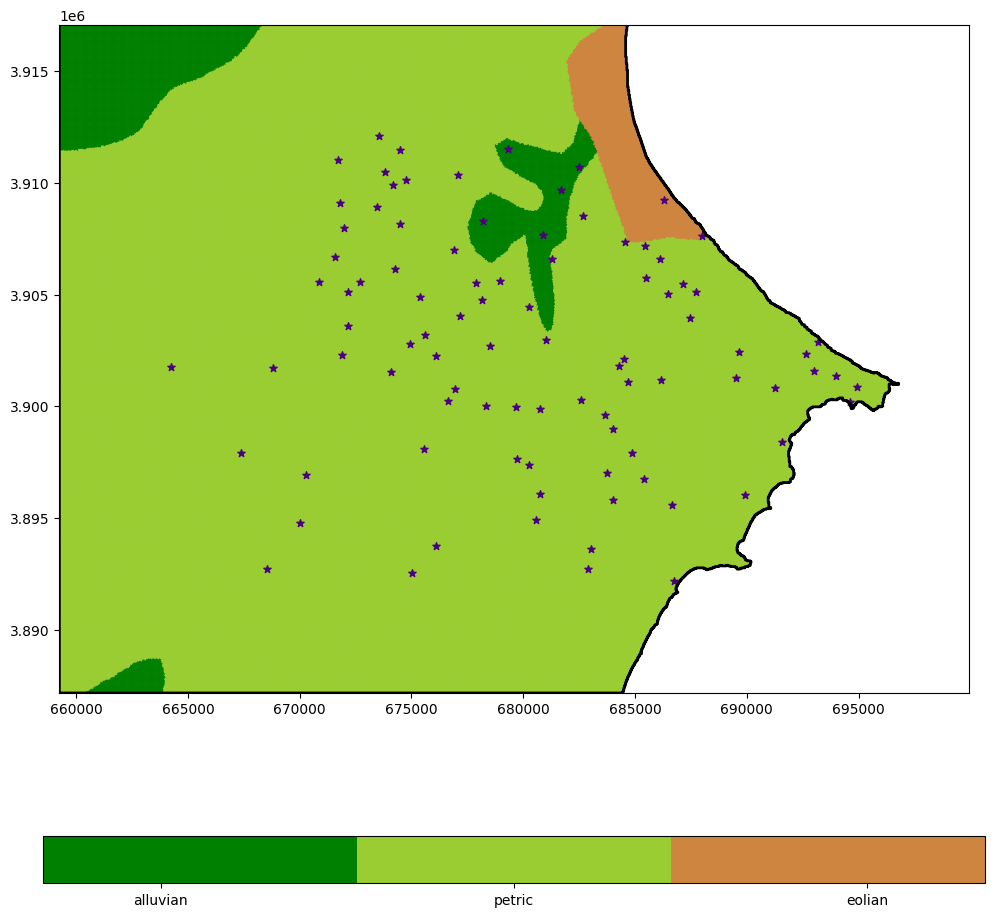

In [99]:
from matplotlib.colors import ListedColormap
from shapely.geometry import box

# Llegir dades
gdf = gpd.read_file("raw_data\chebba__polygon.shp")
cells = pd.read_csv("input_data/preprocessed_grid.csv")
settlements = pd.read_excel("../data/Complete_dataset.xlsx", sheet_name="Chebba sites")

# Definir bbox a partir dels assentaments i afegir un buffer perquè no quedi massa ajustat
x_min, x_max = settlements['X (32S WGS84)'].min(), settlements['X (32S WGS84)'].max()
y_min, y_max = settlements['Y (32S WGS84)'].min(), settlements['Y (32S WGS84)'].max()
buffer = 5000  # ajusta-ho segons la unitat CRS i el grau de retallat que vulguis
crop_box = box(x_min - buffer, y_min - buffer, x_max + buffer, y_max + buffer)

gdf_clipped = gpd.clip(gdf, crop_box)
gdf_clipped.to_file("input_data/chebba_clipped.shp")

# Retallar també les cel·les per no dibuixar punts fora de la zona d'interès
cells_clipped = cells[
    (cells['x'] >= x_min - buffer) &
    (cells['x'] <= x_max + buffer) &
    (cells['y'] >= y_min - buffer) &
    (cells['y'] <= y_max + buffer)
].copy()

fig, ax = plt.subplots(figsize=(10, 10))
gdf_clipped.boundary.plot(ax=ax, color="black", linewidth=2)

cmap = ListedColormap(["green", "yellowgreen", "peru"])
scatter = ax.scatter(
    cells_clipped["x"],
    cells_clipped["y"],
    c=cells_clipped["soil"],
    cmap=cmap,
    s=2,
    linewidths=0,
)
ax.scatter(settlements['X (32S WGS84)'], settlements['Y (32S WGS84)'], marker="*", color="indigo", s=30)

plt.xlim(x_min - buffer, x_max + buffer)
plt.ylim(y_min - buffer, y_max + buffer)

cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal")
cbar.set_ticks([1.25, 2, 2.75])
cbar.set_ticklabels(["alluvian", "petric", "eolian"])

plt.tight_layout()
plt.show()

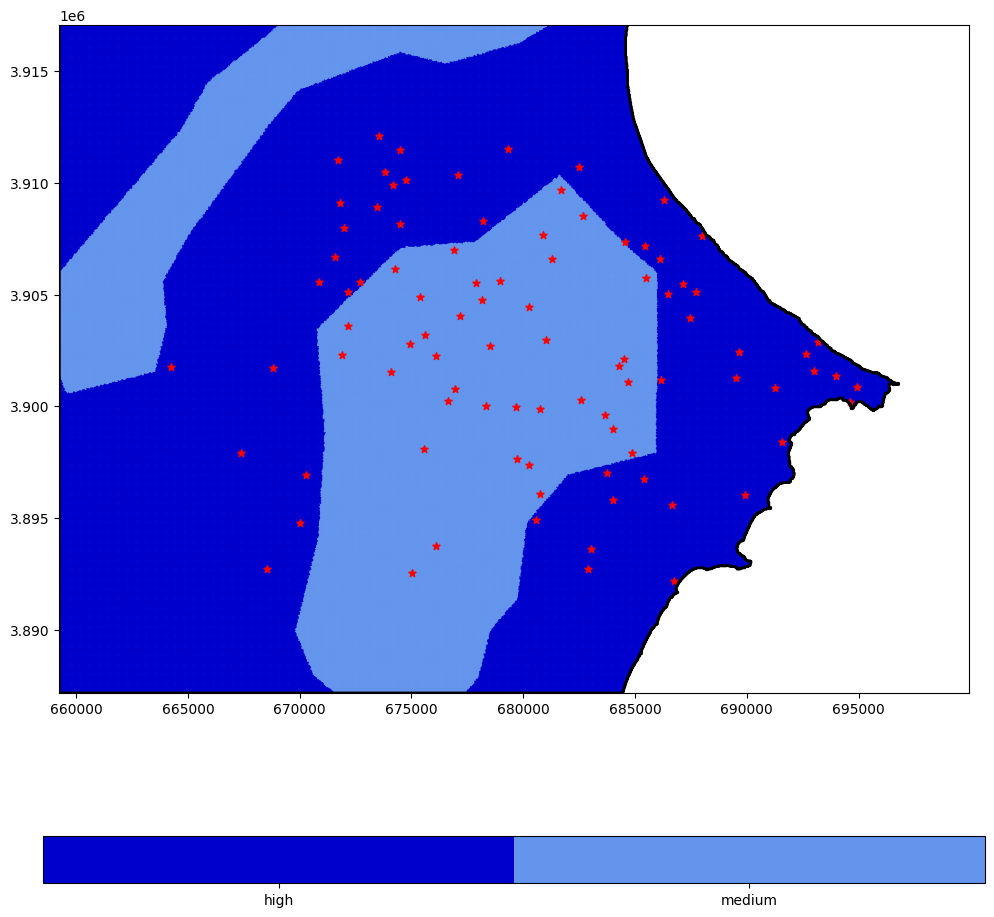

In [90]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_clipped.boundary.plot(ax=ax, color="black", linewidth=2)

cmap = ListedColormap(["mediumblue","cornflowerblue"])
scatter = ax.scatter(
    cells_clipped["x"],
    cells_clipped["y"],
    c=cells_clipped["hydro"],
    cmap=cmap,
    s=2,
    linewidths=0,
)
ax.scatter(settlements['X (32S WGS84)'], settlements['Y (32S WGS84)'], marker="*", color="red", s=30)

plt.xlim(x_min - buffer, x_max + buffer)
plt.ylim(y_min - buffer, y_max + buffer)

cbar = plt.colorbar(scatter, ax=ax, orientation="horizontal")
cbar.set_ticks([1.25, 1.75])
cbar.set_ticklabels(["high", "medium"])

plt.tight_layout()
plt.show()

### Convert the GIS grid into a numpy grid with NN

In [91]:
from shapely.geometry import Point
from shapely.ops import unary_union

L_cell = 250
x0 = x_min - buffer
x1 = x_max + buffer
y0 = y_min - buffer
y1 = y_max + buffer

# Definir arestes i centres del grid 2D
x_edges = np.arange(x0, x1 + L_cell, L_cell)
y_edges = np.arange(y0, y1 + L_cell, L_cell)
nx = len(x_edges) - 1
ny = len(y_edges) - 1

x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
Xc, Yc = np.meshgrid(x_centers, y_centers)

print(f"Regular {L_cell} m grid created with {nx * ny} cells ({ny}x{nx})")

# Reparar geometries invalides abans de fer la unió
safe_geoms = [geom.buffer(0) if geom is not None and not geom.is_valid else geom for geom in gdf.geometry]
gdf = gdf.set_geometry(safe_geoms)
gdf = gdf[gdf.geometry.notna()].copy()

# Excloure les cel·les fora del polígon
poly = unary_union(gdf.geometry)
cell_inside = np.array([
    poly.covers(Point(x, y))
    for x, y in zip(Xc.ravel(), Yc.ravel())
]).reshape(ny, nx)

mask = np.where(cell_inside, 1.0, np.nan)

# regular_grid ara és un grid 2D
regular_grid = {
    "x_center": Xc,
    "y_center": Yc,
    "soil": np.full((ny, nx), np.nan),
    "hydro": np.full((ny, nx), np.nan),
    "mask": mask,
}

print('Cells inside the polygon:', int(cell_inside.sum()))
print('Cells outside the polygon:', int(cell_inside.size - cell_inside.sum()))

Regular 250 m grid created with 19560 cells (120x163)
Cells inside the polygon: 14144
Cells outside the polygon: 5416


In [108]:
py_grid_points = gpd.GeoDataFrame(
    py_grid,
    geometry=gpd.points_from_xy(py_grid.x, py_grid.y),
    crs=gdf.crs
)

# Convertir el grid 2D a punts per fer NN
regular_centroids = gpd.GeoDataFrame(
    {
        "row": np.repeat(np.arange(ny), nx),
        "col": np.tile(np.arange(nx), ny),
    },
    geometry=gpd.points_from_xy(
        regular_grid["x_center"].ravel(),
        regular_grid["y_center"].ravel(),
    ),
    crs=gdf.crs,
)

nearest = gpd.sjoin_nearest(
    regular_centroids,
    py_grid_points[["soil", "hydro", "geometry"]],
    how='left',
    distance_col='nn_dist'
)

# Tornar a forma 2D i aplicar la màscara
soil_2d = nearest['soil'].to_numpy().reshape(ny, nx)
hydro_2d = nearest['hydro'].to_numpy().reshape(ny, nx)
regular_grid['soil'] = soil_2d * regular_grid['mask']
regular_grid['hydro'] = hydro_2d * regular_grid['mask']
regular_grid['nx'] = nx
regular_grid['ny'] = ny
regular_grid['L_cell'] = L_cell
regular_grid['x_min'] = x0
regular_grid['y_min'] = y0
regular_grid['x_max'] = x1
regular_grid['y_max'] = y1

# Guardar el resultat
pd.to_pickle(regular_grid, "input_data/regular_grid.pkl")

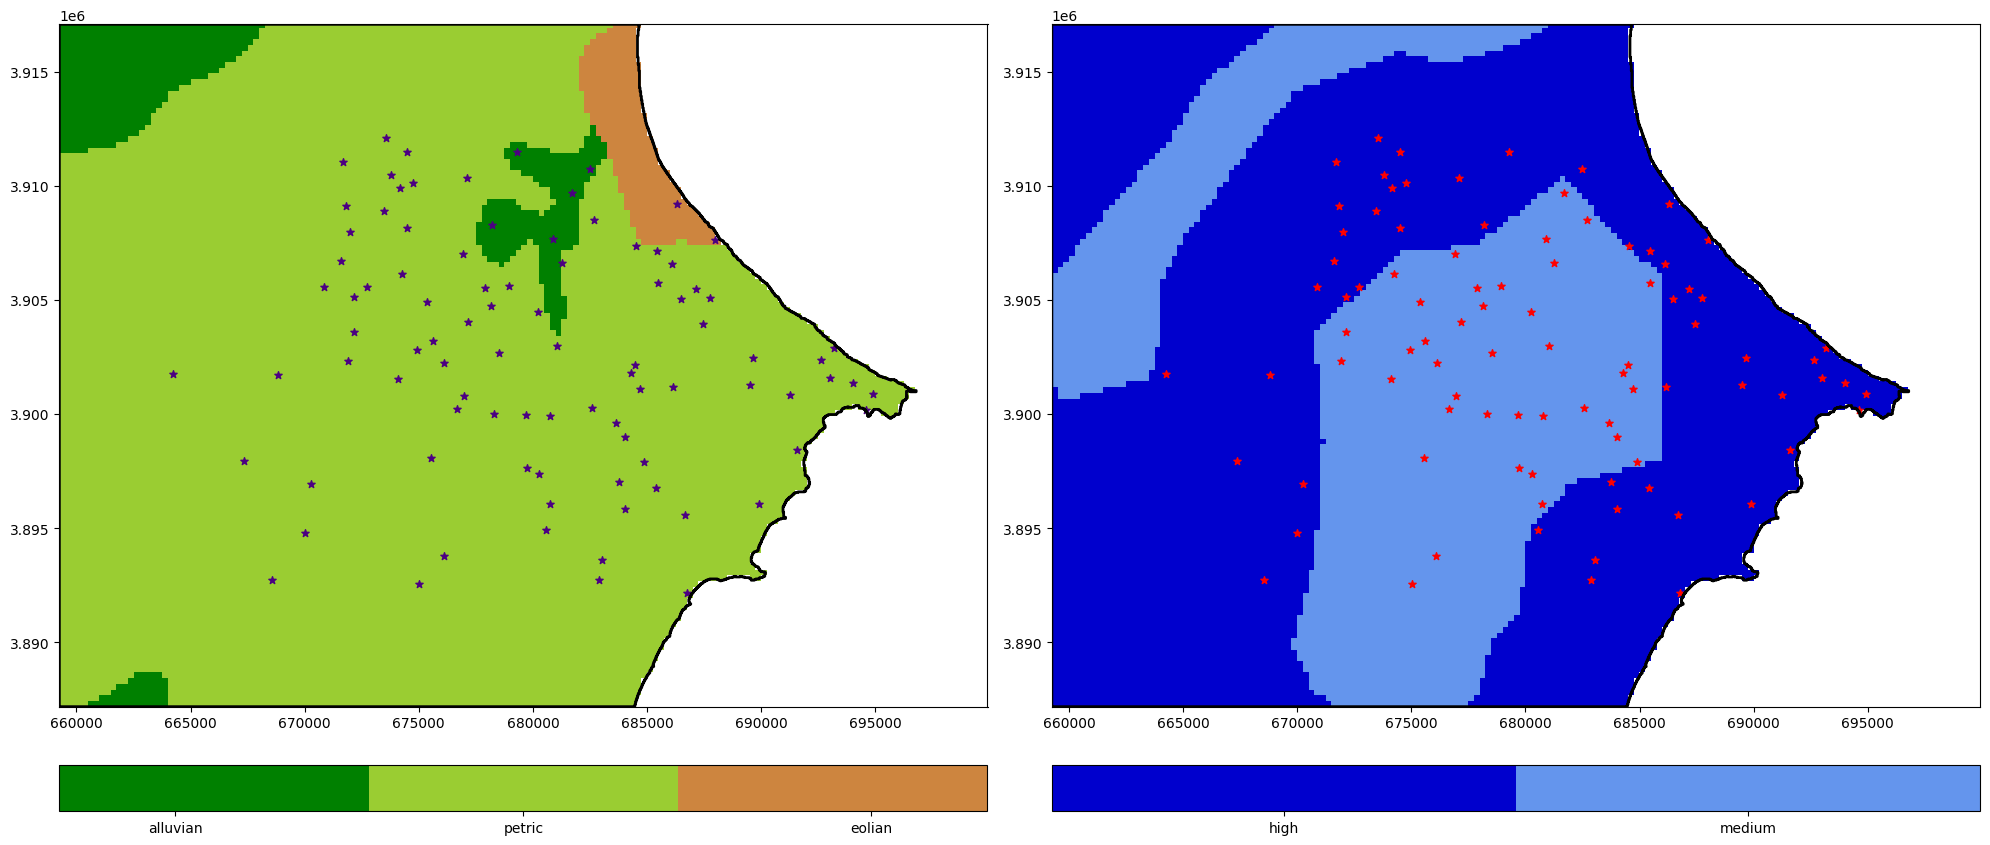

In [100]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
gdf_clipped.boundary.plot(ax=ax[0], color='black', linewidth=2)
gdf_clipped.boundary.plot(ax=ax[1], color='black', linewidth=2)

soil_mesh = ax[0].pcolormesh(
    x_edges,
    y_edges,
    regular_grid['soil'],
    cmap = ListedColormap(["green", "yellowgreen", "peru"]),
    shading='auto',
)
hydro_mesh = ax[1].pcolormesh(
    x_edges,
    y_edges,
    regular_grid['hydro'],
    cmap=ListedColormap(["mediumblue", "cornflowerblue"]),
    shading='auto',
)

ax[0].scatter(settlements['X (32S WGS84)'], settlements['Y (32S WGS84)'], marker='*', color='indigo', s=30)
ax[1].scatter(settlements['X (32S WGS84)'], settlements['Y (32S WGS84)'], marker='*', color='red', s=30)

ax[0].set_xlim(x0, x1)
ax[0].set_ylim(y0, y1)
ax[1].set_xlim(x0, x1)
ax[1].set_ylim(y0, y1)

cbar1 = fig.colorbar(soil_mesh, ax=ax[0], orientation='horizontal', pad=0.06)
cbar1.set_ticks([1.25, 2, 2.75])
cbar1.set_ticklabels(["alluvian", "petric", "eolian"])

cbar2 = fig.colorbar(hydro_mesh, ax=ax[1], orientation='horizontal', pad=0.06)
cbar2.set_ticks([1.25, 1.75])
cbar2.set_ticklabels(["high", "medium"])

plt.tight_layout()
plt.show()

## Preprocess settlements detaset

In [ ]:
sites = pd.DataFrame()
settlements_processed = settlements.copy()
IDs = settlements_processed['ID']
ids = []
x_vals = []
y_vals = []
types = []

for i, ID in enumerate(IDs):
    id_raw = float(ID.split(" ")[1])
    if id_raw.is_integer():
        ids.append(int(id_raw))
        x_vals.append(settlements_processed.iloc[i]['X (32S WGS84)'])
        y_vals.append(settlements_processed.iloc[i]['Y (32S WGS84)'])
        types.append(settlements_processed.iloc[i]['Type'])

sites['id'] = ids
sites['x'] = x_vals
sites['y'] = y_vals
sites['type'] = pd.Series(types).replace(np.nan, 0)
sites.to_csv("input_data/sites.csv", index=False)


,id,x,y,type


,ID,X (32S WGS84),Y (32S WGS84),Name,Type_probable,Type,Settlement category based on survey,River_dist,Road_dist,Near_500,...,CLAF_FAO,Soil_name,Soil_group,Soil_limitation,Soil_agri_potential,Soil_agri_score,TunGLG,TunHGComb,Aquifer_productivity,Archaeology
52,AAT 53,684699,3901104,N/D,1.0,NaN,Villa?,772.075919,4956.702269,523.142542,...,CLp,Petric Calcisols,Calcisol,Petrocalcic hardpan / restricted rooting,Low,2,Cretaceous-Tertiary sedimentary,CSIF-M,3,NaN
82,AAT 83,680553,3894908,Henchir Oulad Slim,NaN,NaN,Kiln,779.576084,5004.405512,87.934072,...,CLp,Petric Calcisols,Calcisol,Petrocalcic hardpan / restricted rooting,Low,2,Unconsolidated,U-H,4,NaN
